# 01 — LUNA16 Data Exploration (Phase 2)

## Objective
Summarise the validated LUNA16 dataset: scan/annotation counts, geometry statistics, nodule size distribution and the scan-level split. Inputs are produced by `scripts/validate_dataset.py`.

## Configuration

In [1]:
from pathlib import Path
META = Path('../data/metadata')
SPLITS = Path('../data/splits')
FIG = Path('../results/figures'); FIG.mkdir(parents=True, exist_ok=True)

## Imports

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})

## Dataset

In [3]:
scans = pd.read_csv(META / 'scans.csv')
ann = pd.read_csv(META / 'annotations_voxel.csv')
print(len(scans), 'scans |', len(ann), 'annotations')
print(Path(META / 'validation_issues.txt').read_text())
scans.groupby('subset').agg(scans=('seriesuid','size'), nodules=('n_nodules','sum'))

888 scans | 1186 annotations
No issues found.



,scans,nodules
subset,,
0,89,112
1,89,128
2,89,128
3,89,119
4,89,128
5,89,108
6,89,129
7,89,111
8,88,118


## Scan geometry

In [4]:
scans[['n_slices','sp_x','sp_z']].describe().round(3)

,n_slices,sp_x,sp_z
count,888.000,888.000,888.000
mean,255.884,0.690,1.570
std,133.761,0.085,0.725
min,95.000,0.461,0.450
25%,137.750,0.625,1.000
50%,237.500,0.703,1.250
75%,305.000,0.742,2.500
max,764.000,0.977,2.500


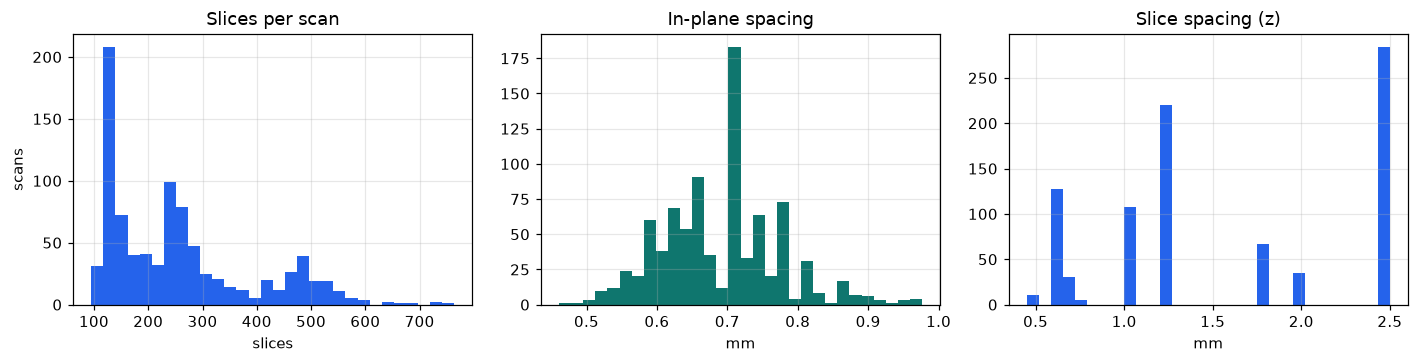

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].hist(scans.n_slices, bins=30, color='#2563EB'); ax[0].set(title='Slices per scan', xlabel='slices', ylabel='scans')
ax[1].hist(scans.sp_x, bins=30, color='#0F766E'); ax[1].set(title='In-plane spacing', xlabel='mm')
ax[2].hist(scans.sp_z, bins=30, color='#2563EB'); ax[2].set(title='Slice spacing (z)', xlabel='mm')
plt.tight_layout(); plt.savefig(FIG / 'exp000_scan_geometry.png'); plt.show()

All scans are 512 × 512 in-plane. Slice spacing is highly variable (0.45–2.5 mm), so resampling (Phase 3) is required before 2.5D slice stacking has a consistent physical meaning.

## Nodules

count    1186.000
mean        8.307
std         4.762
min         3.253
25%         5.107
50%         6.434
75%         9.696
max        32.270
Name: diameter_mm, dtype: float64
Scans with 0 nodules: 287


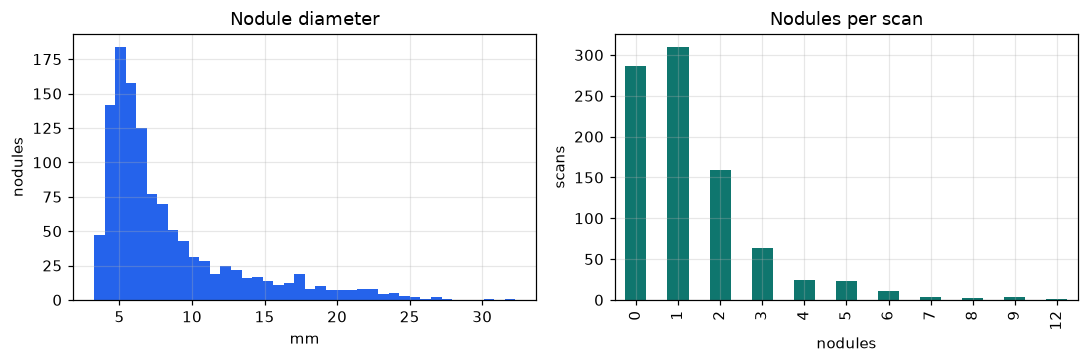

In [6]:
print(ann.diameter_mm.describe().round(3))
print('Scans with 0 nodules:', int((scans.n_nodules==0).sum()))
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].hist(ann.diameter_mm, bins=40, color='#2563EB'); ax[0].set(title='Nodule diameter', xlabel='mm', ylabel='nodules')
scans.n_nodules.value_counts().sort_index().plot.bar(ax=ax[1], color='#0F766E'); ax[1].set(title='Nodules per scan', xlabel='nodules', ylabel='scans')
plt.tight_layout(); plt.savefig(FIG / 'exp000_nodule_stats.png'); plt.show()

## Orientation / coordinate check

In [7]:
print('Scans with flipped x/y axes:', int(((scans.flip_x<0)|(scans.flip_y<0)).sum()))
print('Annotations inside volume after world->voxel conversion:', int(ann.in_bounds.sum()), '/', len(ann))

Scans with flipped x/y axes: 14
Annotations inside volume after world->voxel conversion: 1186 / 1186


14 scans store x/y axes flipped (`TransformMatrix` diag −1, −1, 1). World→voxel conversion must apply the direction matrix (`ScanInfo.world_to_voxel`); ignoring it puts 24 annotations outside the volume.

## Candidates

In [8]:
stats = json.loads((META / 'dataset_stats.json').read_text())
pd.Series({k: stats[k] for k in ['candidates_v1','candidates_v1_pos','candidates_v2','candidates_v2_pos']})

candidates_v1        551065
candidates_v1_pos      1351
candidates_v2        754975
candidates_v2_pos      1557
dtype: int64

Candidates are extremely imbalanced (~0.2% positives), motivating the focal loss in the training objective.

## Split (scan level, no leakage)

In [9]:
info = json.loads((SPLITS / 'split_info.json').read_text()); print(info)
split = {n: set(pd.read_csv(SPLITS / f'{n}.csv').seriesuid) for n in ['train','val','test']}
assert not (split['train'] & split['val'] or split['train'] & split['test'] or split['val'] & split['test'])
rows = [(n, len(u), int(ann.seriesuid.isin(u).sum())) for n, u in split.items()]
pd.DataFrame(rows, columns=['split','scans','nodules'])

{'method': 'subset-level (scan-level) split', 'subsets': {'train': [0, 1, 2, 3, 4, 5, 6, 7], 'val': [8], 'test': [9]}, 'seed': None, 'counts': {'train': 712, 'val': 88, 'test': 88}}


,split,scans,nodules
0,train,712,963
1,val,88,118
2,test,88,105


## Conclusion
The dataset loads, all 888 scans and 1186 annotations are consistent, raw sizes match headers, and a leakage-free scan-level split is defined. Phase 2 gate: dataset pipeline is reliable → continue to Phase 3.